<a href="https://colab.research.google.com/github/mahathi-kannan/enterprise-data-analytics-pipeline/blob/main/03-user-telemetry-analytics/web_traffic_telemetry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your specific web telemetry dataset
df = pd.read_csv('website_wata.csv')

# Look at the structural specifications of your data
print("--- Web Telemetry Data Preview ---")
print(df.head())

print("\n--- Structural Information ---")
print(df.info())

--- Web Telemetry Data Preview ---
   Page Views  Session Duration  Bounce Rate Traffic Source  Time on Page  \
0           5         11.051381     0.230652        Organic      3.890460   
1           4          3.429316     0.391001         Social      8.478174   
2           4          1.621052     0.397986        Organic      9.636170   
3           5          3.629279     0.180458        Organic      2.071925   
4           5          4.235843     0.291541           Paid      1.960654   

   Previous Visits  Conversion Rate  
0                3              1.0  
1                0              1.0  
2                2              1.0  
3                3              1.0  
4                5              1.0  

--- Structural Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Page Views        2000 non-null   int

In [4]:
# Check and remove any duplicate session strings
initial_rows = len(df)
df = df.drop_duplicates()
final_rows = len(df)

print(f"Deduplication complete. Removed {initial_rows - final_rows} duplicate session logs.")
print(f"Total verified operational records: {final_rows}")

Deduplication complete. Removed 0 duplicate session logs.
Total verified operational records: 2000


/tmp/ipykernel_646/1353681220.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Traffic Source', order=source_order, palette='Blues_r')


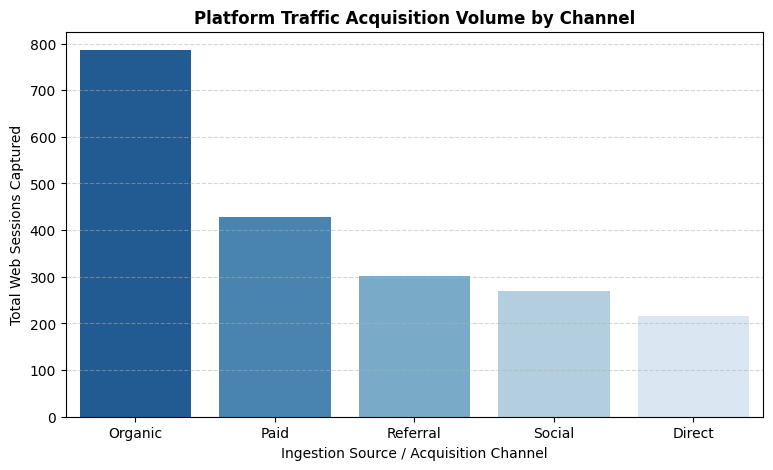

In [5]:
plt.figure(figsize=(9, 5))

# Order the bars from highest traffic source to lowest
source_order = df['Traffic Source'].value_counts().index

sns.countplot(data=df, x='Traffic Source', order=source_order, palette='Blues_r')

plt.title('Platform Traffic Acquisition Volume by Channel', fontsize=12, fontweight='bold')
plt.xlabel('Ingestion Source / Acquisition Channel')
plt.ylabel('Total Web Sessions Captured')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

/tmp/ipykernel_646/947848293.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Traffic Source', y='Session Duration', palette='Set2')


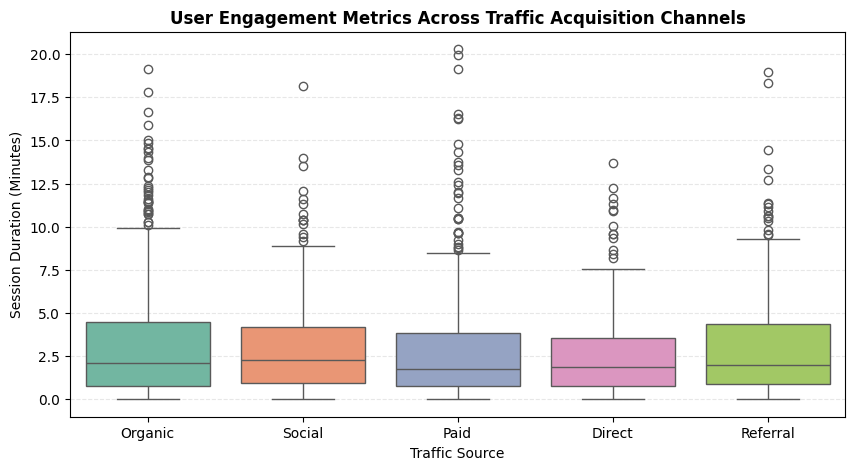

In [6]:
plt.figure(figsize=(10, 5))

# Generate a boxplot comparing traffic channels against actual time spent on-site
sns.boxplot(data=df, x='Traffic Source', y='Session Duration', palette='Set2')

plt.title('User Engagement Metrics Across Traffic Acquisition Channels', fontsize=12, fontweight='bold')
plt.xlabel('Traffic Source')
plt.ylabel('Session Duration (Minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

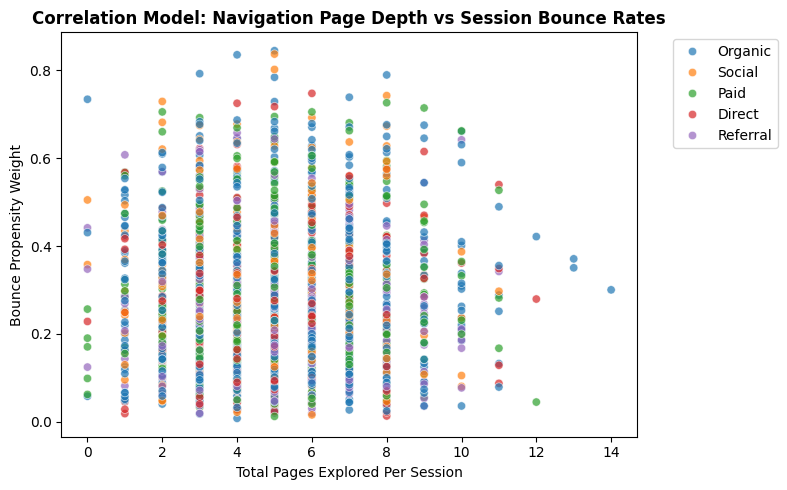

In [7]:
plt.figure(figsize=(8, 5))

# Scatter plot looking at how user page view choices map out against overall bounce limits
sns.scatterplot(data=df, x='Page Views', y='Bounce Rate', hue='Traffic Source', alpha=0.7)

plt.title('Correlation Model: Navigation Page Depth vs Session Bounce Rates', fontsize=12, fontweight='bold')
plt.xlabel('Total Pages Explored Per Session')
plt.ylabel('Bounce Propensity Weight')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()